In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

In [87]:
covid = pd.read_csv('time_series_covid_19_confirmed_US.csv')
covid_state = pd.read_csv('COVID19_state.csv')

Lets explore the data

In [65]:
print(covid.info(), covid.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3342 entries, 0 to 3341
Columns: 505 entries, UID to 5/29/2021
dtypes: float64(3), int64(496), object(6)
memory usage: 12.9+ MB
None                 UID        code3          FIPS          Lat        Long_  \
count  3.342000e+03  3342.000000   3332.000000  3342.000000  3342.000000   
mean   8.342992e+07   834.494913  33043.078932    36.721617   -88.642045   
std    4.314076e+06    36.487378  18648.808931     9.079322    21.776287   
min    1.600000e+01    16.000000     60.000000   -14.271000  -174.159600   
25%    8.401811e+07   840.000000  19076.500000    33.896803   -97.803595   
50%    8.402921e+07   840.000000  31012.000000    38.005610   -89.488865   
75%    8.404612e+07   840.000000  47129.500000    41.579255   -82.313398   
max    8.410000e+07   850.000000  99999.000000    69.314792   145.673900   

         1/22/2020    1/23/2020    1/24/2020    1/25/2020    1/26/2020  ...  \
count  3342.000000  3342.000000  3342.000000  3342.00

Modify the time_series_covid_19_confirmed_US.csv file to include a column containing the first recorded date of a confirmed case of COVID-19

In [55]:
# select the columns containing the time series and generate a boolean mask for dates containing confirmed cases
dates = covid.iloc[:, 11:] != 0

# idxmax will return the first index in the event that no values are True, therefore we will convert False values into NaN
dates = dates.replace(False, np.nan)

# generate a column that contains the date of the first confirmed case for each row

covid['first_case_date'] = dates.idxmax(axis=1)

covid['ranked_first_case_date'] = covid['first_case_date'].rank()

covid.to_csv('covid_modified.csv')

Bin time series data into months

In [56]:
jan = covid.iloc[:, 11:21].sum(axis=1)
feb = covid.iloc[:, 21:50].sum(axis=1)
march = covid.iloc[:, 50:82].sum(axis=1)
april = covid.iloc[:, 82:113].sum(axis=1)
may = covid.iloc[:, 113:144].sum(axis=1)
june = covid.iloc[:, 144:174].sum(axis=1)
july = covid.iloc[:, 174:205].sum(axis=1)
aug = covid.iloc[:, 205:236].sum(axis=1)
sep = covid.iloc[:, 236:266].sum(axis=1)
oct = covid.iloc[:, 266:297].sum(axis=1)
nov = covid.iloc[:, 297:327].sum(axis=1)
dec = covid.iloc[:, 327:358].sum(axis=1)
jan1 = covid.iloc[:, 358:389].sum(axis=1)
feb1 = covid.iloc[:, 389:417].sum(axis=1)
march1 = covid.iloc[:, 417:448].sum(axis=1)
april1 = covid.iloc[:, 448:479].sum(axis=1)
may1 = covid.iloc[:, 479:-2].sum(axis=1)

covid_time_series = pd.concat([jan, feb, march, april, may, june, july, aug, sep, oct, nov, dec, jan1, feb1, march1, april1, may1], axis=1)
covid_time_series.columns = ['2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05']
covid_time_series = pd.DataFrame(covid_time_series.sum().reset_index())
covid_time_series.columns = ['Date', 'Num of Infected']
covid_time_series.to_csv('covid_time_series.csv')

Generate a correlation matrix

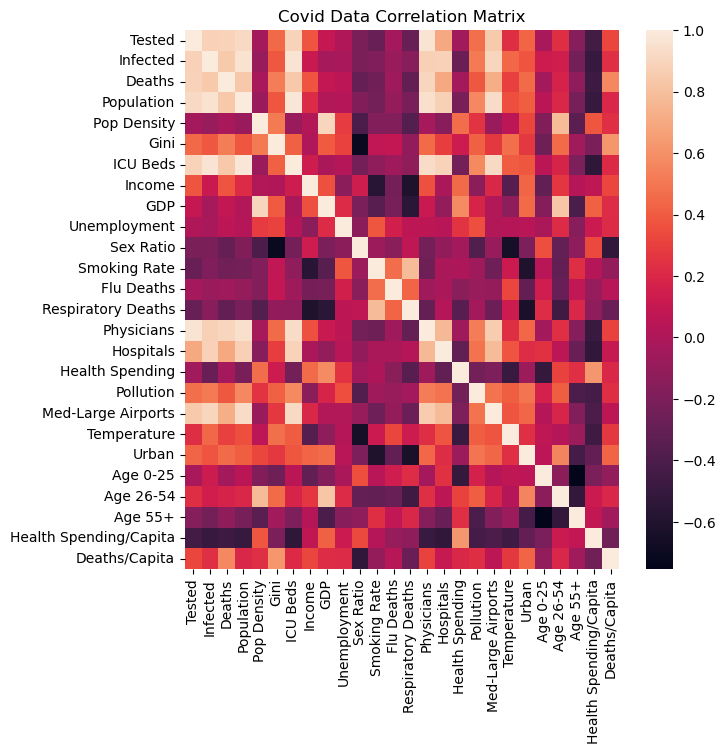

<Figure size 640x480 with 0 Axes>

In [97]:
covid_state['Health Spending/Capita'] = covid_state['Health Spending'] / covid_state['Population']
covid_state['Deaths/Capita'] = covid_state['Deaths'] / covid_state['Population']
covid_state.to_csv('covid_state_modified.csv')
covid_correlation = pd.DataFrame(covid_state.iloc[:,np.r_[1:25, 26:28]])
corr = covid_correlation.corr()
plt.figure(figsize=(7,7))
sns.heatmap(corr)
plt.title('Covid Data Correlation Matrix')
plt.show()
plt.clf()

Perform a linear regression on 'Deaths/Capita' and 'Health Spending/Pop'

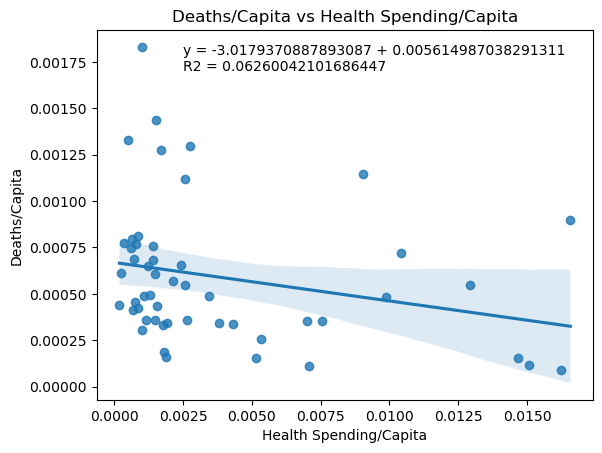

<Figure size 640x480 with 0 Axes>

In [109]:
model = LinearRegression()
model.fit(covid_state[['Deaths/Capita']], covid_state[['Health Spending/Capita']])
R2 = model.score(covid_state[['Deaths/Capita']], covid_state[['Health Spending/Capita']])
coeficient = model.coef_[0][0]
intercept = model.intercept_[0]
equation = str('y = ' + str(coeficient) + ' + ' + str(intercept) + '\nR2 = ' + str(R2))
sns.regplot(data=covid_state, x="Health Spending/Capita", y='Deaths/Capita')
plt.title('Deaths/Capita vs Health Spending/Capita')
plt.text(0.0025, 0.0017, equation)
plt.show()
plt.clf()